# 多层与稳健 meta:依赖效应量怎么办

上一本([22 · Meta 分析入门](22_meta_analysis_basics.ipynb))里,每项研究只贡献**一个**效应量,
研究之间彼此独立,标准的两层随机效应就够用。但真实的证据合成常常不是这样:一项研究会同时
报告**多个结局**(抑郁 + 焦虑)、**多个时点**(3 个月 / 6 个月)、**多个亚组**(男 / 女)——
这些效应量都来自**同一批被试**,彼此**相依**。把它们当成独立观测直接丢进两层模型,会**低估
不确定性**:你以为有 52 个独立信息点,其实只有约 20 项研究那么多。

这本 notebook 用一份**患病率(比例)meta** 作载体(20 项研究、约 52 个相依效应量嵌在里面,
真值 logit-患病率 ≈ 35%),走通处理相依效应量的两条主线:

1. **多层(三层)模型 `rma_mv`**:显式建模抽样协方差 `V`(`vcalc` 按簇内相关 ρ 插补),
   把总异质性分解成 **level-2(研究内 / 结局间,σ²₂)** 与 **level-3(研究间,σ²₃)** 两块方差;
2. **簇稳健方差(CR2)**:不去建模协方差结构,而是用 sandwich 估计量让标准误对簇内相依**稳健**
   ——`ma_robust` / `ma_che`(CHE 工作模型)/ `robu`(robumeta CORR/HIER),再用 `ma_rho_sensitivity`
   检查结论对 ρ 假设是否稳健。

附带演示**比例 meta** 的两个专属步骤:`es_proportion` 的 **arcsine / logit 变换**(把 0–1 的比例
拉到方差稳定的尺度合并),以及 `backtransform_proportion` 的**回变换**(把合并结果搬回可解释的
患病率)。`ma_aggregate` 则给出一个「先把每研究的相依效应量合成一个复合效应量」的简化替代。

> **对标**:R `metafor::rma.mv` / `clubSandwich::coef_test`(CR2)/ `robumeta`。

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. 数据:相依效应量长什么样

**解决什么问题**:先看清「相依」在数据里长什么样——同一 `study` 下有多行,就是同一批被试的多个
效应量。**关键前提**:必须有一个**簇标识列**(这里是 `study`),后面所有多层 / 稳健方法都靠它把
相依的行归到一起。

`load_meta_prevalence()` 合成了 20 项研究,每项贡献 1–4 个患病率估计。每行给一个 `cases`(病例数)
和 `n`(样本量)。**真值**(数据生成时写死的):总体 logit-患病率 = −0.6(≈ 35% 患病率),
研究间 SD = 0.30(→ σ²₃ ≈ 0.09),研究内 / 结局间 SD = 0.20(→ σ²₂ ≈ 0.04)。后面就看这些估计量
能不能把这三个真值找回来。

In [2]:
prev = ds.load_meta_prevalence(seed=0)
n_studies = prev["study"].nunique()
print(f"效应量(行数)= {len(prev)}   研究数 = {n_studies}   平均每研究 {len(prev)/n_studies:.1f} 个效应量")
print("每研究效应量个数分布:", prev.groupby("study").size().value_counts().sort_index().to_dict())
prev.head(8)

效应量(行数)= 56   研究数 = 20   平均每研究 2.8 个效应量
每研究效应量个数分布: {1: 5, 2: 1, 3: 7, 4: 7}


,study,cases,n,year,female_pct,instrument
0,S00,47,137,2008,0.80,CES-D
1,S00,106,258,2008,0.75,BDI
2,S00,6,40,2008,0.70,BDI
3,S01,20,68,2009,0.32,PHQ-9
4,S02,119,281,2010,0.85,BDI
5,S03,123,342,2011,0.70,BDI
6,S03,73,175,2011,0.61,PHQ-9
7,S03,120,299,2011,0.79,CES-D


## 2. 效应量:比例 → logit 变换

**解决什么问题**:比例(患病率)天然被限制在 0–1,直接合并有两个毛病——靠近 0 或 1 时方差被压缩、
置信区间会溢出 [0,1]。**关键前提**:先做**方差稳定变换**。`es_proportion` 支持 `PLO`(logit,默认、
最稳)/ `PAS`(arcsine)/ `PFT`(Freeman-Tukey 双反正弦)等。**哪几步**:传 `cases=` 和 `n=`,选
`measure="PLO"`,并把 `study` 同时声明为**簇**(`cluster=`)和研究标签(`study=`)——这样后面的
`vcalc` / `rma_mv` / 稳健方差才能找到分簇信息。

我们同时算一份 arcsine(`PAS`)版本存到旁边,后面第 8 节做回变换对比时用。

In [3]:
study = sv.StudyState()
study.write("sources", "datasets", prev)

# 主路径:logit(PLO)效应量,study 既是簇也是标签
sv.pp.es_proportion(study, measure="PLO",
                    cases="cases", n="n",
                    cluster="study", study="study", slab="study",
                    moderators=["year", "female_pct"], append=False)

eff = study.models["meta_effects"]
print("效应量表列:", list(eff.columns))
print(f"logit 尺度平均 yi = {eff['yi'].mean():.3f}  →  回到比例 ≈ {1/(1+np.exp(-eff['yi'].mean())):.1%}"
      f"   (真值 35%)")
eff.head(6).round(4)

效应量表列: ['yi', 'vi', 'sei', 'measure', 'study', 'cluster', 'slab', 'year', 'female_pct']
logit 尺度平均 yi = -0.606  →  回到比例 ≈ 35.3%   (真值 35%)


,yi,vi,sei,measure,study,cluster,slab,year,female_pct
0,-0.6497,0.0324,0.1800,PLO,S00,S00,S00,2008,0.80
1,-0.3604,0.0160,0.1265,PLO,S00,S00,S00,2008,0.75
2,-1.7346,0.1961,0.4428,PLO,S00,S00,S00,2008,0.70
3,-0.8755,0.0708,0.2661,PLO,S01,S01,S01,2009,0.32
4,-0.3085,0.0146,0.1207,PLO,S02,S02,S02,2010,0.85
5,-0.5769,0.0127,0.1127,PLO,S03,S03,S03,2011,0.70


## 3. 为什么两层不够:先看一个"天真"的两层拟合

**解决什么问题**:直观展示「把相依效应量当独立」的后果。**关键前提**:两层 `meta_random` 假设
52 行**互相独立**——但它们其实嵌在 20 项研究里。**哪几步**:先跑一次标准两层随机效应,记下它的
标准误;等第 4–5 节做完三层 / 稳健版,再回来对比——正确处理相依后,总估计的 SE 一般会**变大**
(更诚实),因为有效信息量没有 52 个那么多。

In [4]:
sv.tl.meta_random(study, method="REML")
re2 = study.models["meta"]
print(f"[天真两层]  logit = {re2['estimate']:.4f}   SE = {re2['se']:.4f}"
      f"   95% CI [{re2['ci_lb']:.3f}, {re2['ci_ub']:.3f}]   τ² = {re2['tau2']:.4f}")
print(f"           → 患病率 ≈ {1/(1+np.exp(-re2['estimate'])):.1%}"
      f"   (把 52 个相依效应量当独立,SE 会偏小)")

[天真两层]  logit = -0.5841   SE = 0.0459   95% CI [-0.674, -0.494]   τ² = 0.0900
           → 患病率 ≈ 35.8%   (把 52 个相依效应量当独立,SE 会偏小)


## 4. 构造抽样协方差 V:vcalc

**解决什么问题**:三层模型 `rma_mv` 需要一个**抽样协方差矩阵 V**,而不是只有对角方差——因为同一
研究内的效应量,其抽样误差是**相关**的。**关键前提**:我们通常不知道真实的簇内相关,于是**假设**
一个 ρ(默认 0.6)。**哪几步**:`vcalc(cluster="study", rho=...)` 造一个块对角矩阵——对角是各自的
`vi`,同簇的非对角是 `ρ·√(vᵢvⱼ)`,不同簇为 0。结果写进 `models["meta_V"]`,喂给下一步。

In [5]:
sv.tl.vcalc(study, cluster="study", rho=0.6)
V = study.models["meta_V"]
print(f"V 形状 = {V.shape}   (= 效应量数 × 效应量数)")
print(f"对角(前 3 个 vi)         = {np.diag(V)[:3].round(4)}")
# 找一个含多个效应量的研究,看它的块内非对角是否被填上
first_multi = eff.groupby("study").size().idxmax()
idx = np.where(eff["study"].to_numpy() == first_multi)[0]
print(f"研究 {first_multi} 含 {len(idx)} 个效应量,其抽样协方差子块:")
np.round(V[np.ix_(idx, idx)], 4)

V 形状 = (56, 56)   (= 效应量数 × 效应量数)
对角(前 3 个 vi)         = [0.0324 0.016  0.1961]
研究 S03 含 4 个效应量,其抽样协方差子块:


array([[0.0127, 0.0104, 0.008 , 0.0082],
       [0.0104, 0.0235, 0.0109, 0.0112],
       [0.008 , 0.0109, 0.0139, 0.0086],
       [0.0082, 0.0112, 0.0086, 0.0147]])

## 5. 三层随机效应:rma_mv

**解决什么问题**:这是本 notebook 的主角。`rma_mv` 拟合**三层**随机效应:第 1 层是抽样误差(已知,
藏在 V 里),第 2 层是**研究内 / 结局间**方差 σ²₂,第 3 层是**研究间**方差 σ²₃。**关键前提**:
必须先跑 `vcalc`(上一步已把 V 存好),并用 `study=` 指定分簇列。**哪几步**:一次调用同时给出
合并估计(截距)和两个方差分量。对比第 3 节的天真两层——总方差 σ²₂+σ²₃ 应接近真值 0.09+0.04=0.13。

In [6]:
sv.tl.rma_mv(study, study="study", method="REML")
mv = study.models["meta"]
print(f"[三层 rma_mv]  合并 logit = {mv['estimate']:.4f}   SE = {mv['se']:.4f}"
      f"   95% CI [{mv['ci_lb']:.3f}, {mv['ci_ub']:.3f}]")
print(f"              → 患病率 ≈ {1/(1+np.exp(-mv['estimate'])):.1%}   (真值 35%)")
print(f"  σ²₂ 研究内/结局间 = {mv['sigma2_2']:.4f}   (真值 ≈ 0.04)")
print(f"  σ²₃ 研究间        = {mv['sigma2_3']:.4f}   (真值 ≈ 0.09)")
print(f"  σ²  合计          = {mv['sigma2_total']:.4f}   收敛 = {mv['converged']}   研究数 = {mv['n_studies']}")
print()
print(f"  对比第 3 节天真两层 SE {re2['se']:.4f} → 三层 SE {mv['se']:.4f}(把相依算进来后更诚实)")

[三层 rma_mv]  合并 logit = -0.5677   SE = 0.0620   95% CI [-0.689, -0.446]
              → 患病率 ≈ 36.2%   (真值 35%)
  σ²₂ 研究内/结局间 = 0.0568   (真值 ≈ 0.04)
  σ²₃ 研究间        = 0.0338   (真值 ≈ 0.09)
  σ²  合计          = 0.0906   收敛 = True   研究数 = 20

  对比第 3 节天真两层 SE 0.0459 → 三层 SE 0.0620(把相依算进来后更诚实)


## 6. 分层 I²:异质性到底来自哪一层

**解决什么问题**:两层 meta 只有一个 I²;三层可以问得更细——「异质性有多少来自**研究之间**、
多少来自**同一研究的不同结局之间**」。**关键前提**:必须先有一个三层拟合(上一步 `rma_mv` 产出了
σ²₂ 和 σ²₃)。**哪几步**:`ma_i2_multilevel` 按 Cheung(2014)把总变异拆成三份——抽样误差占比、
level-2 占比、level-3 占比,三者相加 = 100%。

In [7]:
sv.tl.ma_i2_multilevel(study)
i2m = study.diagnostics["i2_multilevel"]
print(f"抽样误差占比            = {i2m['sampling_share']:.1f}%")
print(f"I²(level-2,研究内)   = {i2m['I2_level2_within_study']:.1f}%")
print(f"I²(level-3,研究间)   = {i2m['I2_level3_between_study']:.1f}%")
print(f"  → 合计 = {i2m['sampling_share']+i2m['I2_level2_within_study']+i2m['I2_level3_between_study']:.1f}%"
      f"   总异质 I² = {i2m['I2_level2_within_study']+i2m['I2_level3_between_study']:.1f}%")

抽样误差占比            = 19.1%
I²(level-2,研究内)   = 50.7%
I²(level-3,研究间)   = 30.2%
  → 合计 = 100.0%   总异质 I² = 80.9%


## 7. τ² 的不确定性 + 预测区间

**解决什么问题**:异质性本身也是**估**出来的,应该报告它的不确定性;高异质下更该关心「未来一项
研究会落在哪」。**关键前提**:`tau2_ci` 直接从效应量算(Q-profile,不依赖前面的模型);
`meta_prediction_interval` 读当前 `models["meta"]`——注意此刻里面是三层拟合结果。**哪几步**:
先取 τ² 的 Q-profile 置信区间,再算 95% 预测区间并回到患病率尺度看跨度。

In [8]:
sv.tl.tau2_ci(study, level=0.95)
tci = study.diagnostics["tau2_ci"]
print(f"τ²(总)95% Q-profile 区间 = [{tci['tau2_lb']:.4f}, {tci['tau2_ub']:.4f}]")
print(f"I² 95% 区间               = [{tci['I2_lb']:.1f}%, {tci['I2_ub']:.1f}%]")

# 剖面似然区间(profile-ML)是另一条路:似然下降 χ²/2 处的界,小 k 下比 Wald 更可靠
sv.tl.ma_profile(study)
prof = study.diagnostics["ma_profile"]
print(f"τ² 剖面似然 95% 区间       = [{prof['tau2_ci'][0]:.4f}, {prof['tau2_ci'][1]:.4f}]  ({prof['method']})")

sv.tl.meta_prediction_interval(study, level=0.95)
pi = study.diagnostics["prediction_interval"]
print(f"\n95% 预测区间 (logit): [{pi['pi_lb']:.3f}, {pi['pi_ub']:.3f}]")
print(f"→ 患病率尺度: [{1/(1+np.exp(-pi['pi_lb'])):.1%}, {1/(1+np.exp(-pi['pi_ub'])):.1%}]"
      f"   未来一项研究的真实患病率可能落在这个较宽的范围里")

τ²(总)95% Q-profile 区间 = [0.0591, 0.1639]
I² 95% 区间               = [73.4%, 88.5%]
τ² 剖面似然 95% 区间       = [0.0543, 0.1445]  (profile-ML)

95% 预测区间 (logit): [-1.184, 0.048]
→ 患病率尺度: [23.4%, 51.2%]   未来一项研究的真实患病率可能落在这个较宽的范围里


## 8. 回变换:把合并的 logit 搬回可解释的患病率

**解决什么问题**:第 2 节把比例拉到 logit 尺度合并,报告时必须**变回** 0–1 的患病率,否则读者读不懂
`logit = −0.6` 是什么。**关键前提**:回变换要知道用的是哪种尺度(PLO / PAS / PFT),从效应量表的
`measure` 自动取。**哪几步**:`backtransform_proportion` 把合并点估计和它的 CI 一起回变换。
我们顺带用一份 **arcsine(PAS)** 效应量重合并 + 回变换,对比两种变换给出的患病率是否一致
(稳健的分析里,两者应很接近)。

In [9]:
# (a) logit 路径的回变换(基于第 5 节的三层拟合)
sv.tl.backtransform_proportion(study)
bt_logit = study.diagnostics["pooled_proportion"]
print(f"[PLO logit] 合并患病率 = {bt_logit['proportion']:.1%}"
      f"   95% CI [{bt_logit['ci_lb']:.1%}, {bt_logit['ci_ub']:.1%}]")

# (b) arcsine 路径:另起一个 StudyState,PAS 变换 → 两层合并 → 回变换
study_pas = sv.StudyState()
study_pas.write("sources", "datasets", prev)
sv.pp.es_proportion(study_pas, measure="PAS", cases="cases", n="n",
                    cluster="study", study="study", slab="study", append=False)
sv.tl.meta_random(study_pas, method="REML")
sv.tl.backtransform_proportion(study_pas)
bt_pas = study_pas.diagnostics["pooled_proportion"]
print(f"[PAS arcsine] 合并患病率 = {bt_pas['proportion']:.1%}"
      f"   95% CI [{bt_pas['ci_lb']:.1%}, {bt_pas['ci_ub']:.1%}]")
print(f"\n→ 两种变换给出的患病率相差 {abs(bt_logit['proportion']-bt_pas['proportion'])*100:.1f} 个百分点"
      f",都稳稳落在真值 35% 附近")

[PLO logit] 合并患病率 = 36.2%   95% CI [33.4%, 39.0%]
[PAS arcsine] 合并患病率 = 35.7%   95% CI [33.7%, 37.8%]

→ 两种变换给出的患病率相差 0.4 个百分点,都稳稳落在真值 35% 附近


## 9. 稳健方差(CR2):不建模协方差,让 SE 稳健

**解决什么问题**:三层模型要**假设**一个协方差结构;另一条路是不做这个假设,而用**簇稳健(sandwich)
方差**——只要按 `study` 聚簇,标准误就对簇内任意相依结构稳健。**关键前提**:簇数(研究数)不能太少;
CR2(Bell-McCaffrey 偏差修正)在小簇数下比 CR0/CR1 更可靠。**哪几步**:`ma_robust(vcov="CR2")`
给出稳健 SE 与 t 检验(默认按 `study` 聚簇、截距-only = 稳健合并均值)。

In [10]:
sv.tl.ma_robust(study, vcov="CR2", cluster="study")
rve = study.models["meta_rve"]
ic = rve["coefs"]["(intercept)"]
print(f"[CR2 稳健]  合并 logit = {ic['estimate']:.4f}   稳健 SE = {ic['se']:.4f}"
      f"   df = {ic['df']}(= 簇数−p)")
print(f"           95% CI [{ic['ci_lb']:.3f}, {ic['ci_ub']:.3f}]   t = {ic['tval']:.2f}  p = {ic['pval']:.3g}")
print(f"           簇数 = {rve['n_clusters']}   vcov = {rve['vcov_type']}")
print(f"  对比:三层 SE {mv['se']:.4f}  vs  CR2 稳健 SE {ic['se']:.4f}(两条路互为印证)")

[CR2 稳健]  合并 logit = -0.5841   稳健 SE = 0.0654   df = 19(= 簇数−p)
           95% CI [-0.721, -0.447]   t = -8.94  p = 3.11e-08
           簇数 = 20   vcov = CR2
  对比:三层 SE 0.0620  vs  CR2 稳健 SE 0.0654(两条路互为印证)


## 10. CHE 工作模型:处理相依效应的推荐默认

**解决什么问题**:Pustejovsky & Tipton(2022)推荐的**默认**做法——**CHE(correlated-hierarchical
effects)工作模型** = 用一个近似的相关-层级权重做加权,再套 CR2 稳健推断。它兼顾了「建模」和
「稳健」两者的好处。**关键前提**:同样按 `study` 聚簇。**哪几步**:`ma_che` 就是 `ma_robust` 的
CR2 预设封装,一行拿到 CHE 结果。

In [11]:
sv.tl.ma_che(study, cluster="study", rho=0.6)
che = study.models["meta_rve"]
iche = che["coefs"]["(intercept)"]
print(f"[CHE 工作模型]  合并 logit = {iche['estimate']:.4f}   稳健 SE = {iche['se']:.4f}")
print(f"               → 患病率 ≈ {1/(1+np.exp(-iche['estimate'])):.1%}   (真值 35%)")
print(f"               95% CI [{iche['ci_lb']:.3f}, {iche['ci_ub']:.3f}]   vcov = {che['vcov_type']}")

[CHE 工作模型]  合并 logit = -0.5841   稳健 SE = 0.0654
               → 患病率 ≈ 35.8%   (真值 35%)
               95% CI [-0.721, -0.447]   vcov = CR2


## 11. robumeta 工作模型:CORR / HIER 权重

**解决什么问题**:经典的 `robumeta`(Hedges/Tipton)提供两种工作模型——**CORR**(相关效应:同一研究
的效应量高度相关)与 **HIER**(层级效应:效应量在研究内还有独立分层)。**关键前提**:选对模型取决于
相依的来源,拿不准时做 ρ 敏感性。**哪几步**:`robu(model="CORR", rho=..., rho_grid=[...])` 一次给出
主结果 + 一条 ρ 网格上的合并估计,看结论稳不稳。

In [12]:
sv.tl.robu(study, model="CORR", rho=0.8, rho_grid=[0.2, 0.5, 0.8], cluster="study")
rb = study.models["meta_rve"]
irb = rb["coefs"]["(intercept)"]
print(f"[robu CORR]  合并 logit = {irb['estimate']:.4f}   稳健 SE = {irb['se']:.4f}"
      f"   t = {irb['tval']:.2f}  p = {irb['pval']:.3g}")
print(f"             工作模型 = {rb['working_model']}   簇数 = {rb['n_clusters']}   df = {rb['df']}")
print("  ρ 网格上的合并 logit(CORR 权重下对 ρ 基本不敏感):")
for r, coef in rb["rho_sensitivity"].items():
    print(f"    ρ = {r}:  intercept = {coef['(intercept)']:.4f}")

[robu CORR]  合并 logit = -0.5789   稳健 SE = 0.0682   t = -8.49  p = 6.9e-08
             工作模型 = CORR   簇数 = 20   df = 19
  ρ 网格上的合并 logit(CORR 权重下对 ρ 基本不敏感):
    ρ = 0.2:  intercept = -0.5789
    ρ = 0.5:  intercept = -0.5789
    ρ = 0.8:  intercept = -0.5789


### 稳健推断三件套:系数检验 · 联合 Wald · 簇诊断

有了稳健方差,配套的**推断**也要用稳健版本。**哪几步**:先带一个调节变量(发表年份)重拟合
CR2 稳健元回归,再跑四件套——`ma_coef_test`(每系数稳健 t 检验)、`ma_wald_test`(对一组调节
变量做**联合** Wald)、`ma_cwb_test`(**簇 wild bootstrap**,簇数少时更可靠的 p)、
`ma_cluster_influence`(留一簇,看哪项研究在驱动结论)。

In [13]:
sv.tl.ma_robust(study, moderators=["year"], vcov="CR2", cluster="study")
sv.tl.ma_coef_test(study)
ct = study.diagnostics["ma_coef_test"]
print("[稳健系数检验 CR2]  各系数 t 检验:")
for name, t in ct["tests"].items():
    print(f"    {name:12s}  β = {t['estimate']:+.4f}  SE = {t['se']:.4f}  t = {t['tval']:+.2f}  p = {t['pval']:.3g}")

sv.tl.ma_wald_test(study)                      # 联合检验全部调节变量 = 0
wald = study.diagnostics["ma_wald_test"]
print(f"\n[联合 Wald]  检验 {wald['terms']}:  F = {wald['F']:.2f}  (df1={wald['df1']}, df2={wald['df2']})  p = {wald['pval']:.3g}")

sv.tl.ma_cwb_test(study, target="year", cluster="study", nboot=299)
cwb = study.diagnostics["ma_cwb_test"]
print(f"[簇 wild bootstrap]  year 系数 p = {cwb['pval_cwb']:.3g}  (簇数 {cwb['n_clusters']},{cwb['nboot']} 次重抽)")

sv.tl.ma_cluster_influence(study, cluster="study")
cinf = study.diagnostics["ma_cluster_influence"]
top = sorted(cinf["rows"], key=lambda r: -abs(r["delta"]))[:3]
print(f"[留一簇影响]  全样本合并 logit = {cinf['full_estimate']:.4f};剔除影响最大的簇后变动:")
for r in top:
    print(f"    去掉 {r['omitted_cluster']:>4s}:  合并 = {r['estimate']:.4f}  (Δ = {r['delta']:+.4f})")

[稳健系数检验 CR2]  各系数 t 检验:
    (intercept)   β = -12.4597  SE = 30.9896  t = -0.40  p = 0.692
    year          β = +0.0059  SE = 0.0154  t = +0.38  p = 0.706

[联合 Wald]  检验 ['year']:  F = 0.15  (df1=1, df2=18)  p = 0.706
[簇 wild bootstrap]  year 系数 p = 0.713  (簇数 20,299 次重抽)
[留一簇影响]  全样本合并 logit = -0.5841;剔除影响最大的簇后变动:
    去掉  S17:  合并 = -0.5540  (Δ = +0.0301)
    去掉  S04:  合并 = -0.5587  (Δ = +0.0254)
    去掉  S09:  合并 = -0.6080  (Δ = -0.0239)


## 12. ρ 敏感性:三层结论对 ρ 假设稳不稳

**解决什么问题**:`vcalc` 里那个 ρ=0.6 是**假设**出来的;负责任的做法是证明「换个 ρ,结论不变」。
**关键前提**:这条会在 ρ 网格上**反复重建 V + 重拟合 rma_mv**,所以只对相依效应量有意义(需要簇列)。
**哪几步**:`ma_rho_sensitivity(cluster="study", rho_grid=[...])` 扫一遍 ρ,报告合并估计的**变动范围**
和一个 `robust` 标志(范围 < 0.1 视为稳健)。

In [14]:
sv.tl.ma_rho_sensitivity(study, cluster="study", rho_grid=[0.0, 0.3, 0.6, 0.9])
rs = study.diagnostics["ma_rho_sensitivity"]
print("ρ 网格上的三层合并估计:")
for row in rs["rows"]:
    print(f"    ρ = {row['rho']:.1f}:  logit = {row['estimate']:.4f}   SE = {row['se']:.4f}"
          f"   σ²_total = {row['tau2']:.4f}")
lo, hi = rs["estimate_range"]
print(f"\n合并估计变动范围 = [{lo:.4f}, {hi:.4f}]  (跨度 {hi-lo:.4f})   稳健 = {rs['robust']}")

ρ 网格上的三层合并估计:
    ρ = 0.0:  logit = -0.5759   SE = 0.0624   σ²_total = 0.0911
    ρ = 0.3:  logit = -0.5719   SE = 0.0622   σ²_total = 0.0903
    ρ = 0.6:  logit = -0.5677   SE = 0.0620   σ²_total = 0.0906
    ρ = 0.9:  logit = -0.5633   SE = 0.0619   σ²_total = 0.0922

合并估计变动范围 = [-0.5759, -0.5633]  (跨度 0.0126)   稳健 = True


## 13. ma_aggregate:相依效应量的简化替代

**解决什么问题**:当研究数偏少、或不想上三层模型时,有一个更简单的替代——把**每项研究**的多个相依
效应量按 Borenstein 公式**合成一个复合效应量**,这样每研究只剩一行,相依问题直接消失,再跑标准两层
即可。**关键前提**:复合方差要把簇内相关 ρ 算进去(否则又低估)。**哪几步**:`ma_aggregate` 把
`meta_effects` 折叠成「每研究一行」,再对复合效应做两层合并。用一个**新的 StudyState**,避免污染
前面的三层 / 稳健结果。

In [15]:
study_agg = sv.StudyState()
study_agg.write("sources", "datasets", prev)
sv.pp.es_proportion(study_agg, measure="PLO", cases="cases", n="n",
                    cluster="study", study="study", slab="study", append=False)

n_before = len(study_agg.models["meta_effects"])
sv.pp.ma_aggregate(study_agg, cluster="study", rho=0.6)
agg_eff = study_agg.models["meta_effects"]
print(f"聚合前效应量 = {n_before}  →  聚合后(每研究一行)= {len(agg_eff)}")

sv.tl.meta_random(study_agg, method="REML")
agg = study_agg.models["meta"]
sv.tl.backtransform_proportion(study_agg)
bt_agg = study_agg.diagnostics["pooled_proportion"]
print(f"[聚合 + 两层]  合并 logit = {agg['estimate']:.4f}   SE = {agg['se']:.4f}")
print(f"              合并患病率 = {bt_agg['proportion']:.1%}"
      f"   95% CI [{bt_agg['ci_lb']:.1%}, {bt_agg['ci_ub']:.1%}]   (真值 35%)")
print("  → 复合法给出的患病率与三层 / CHE 一致,是一个快速的合理性检查")

聚合前效应量 = 56  →  聚合后(每研究一行)= 20
[聚合 + 两层]  合并 logit = -0.5823   SE = 0.0677
              合并患病率 = 35.8%   95% CI [32.8%, 38.9%]   (真值 35%)
  → 复合法给出的患病率与三层 / CHE 一致,是一个快速的合理性检查


## 14. 森林图:把相依结构画进一张图

**解决什么问题**:森林图是标准输出。这里用**聚合后**的「每研究一行」效应量画森林图——既避免 52 行
挤成一团,又直观呈现研究层面的证据 + 合并菱形 + 预测区间。**关键前提**:`meta_forest` 需要
`meta_effects` 和一个已拟合的 `meta`(上一步的聚合两层拟合都有)。**哪几步**:补一个异质性诊断
让图注带上 I²/τ²,再画图。

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


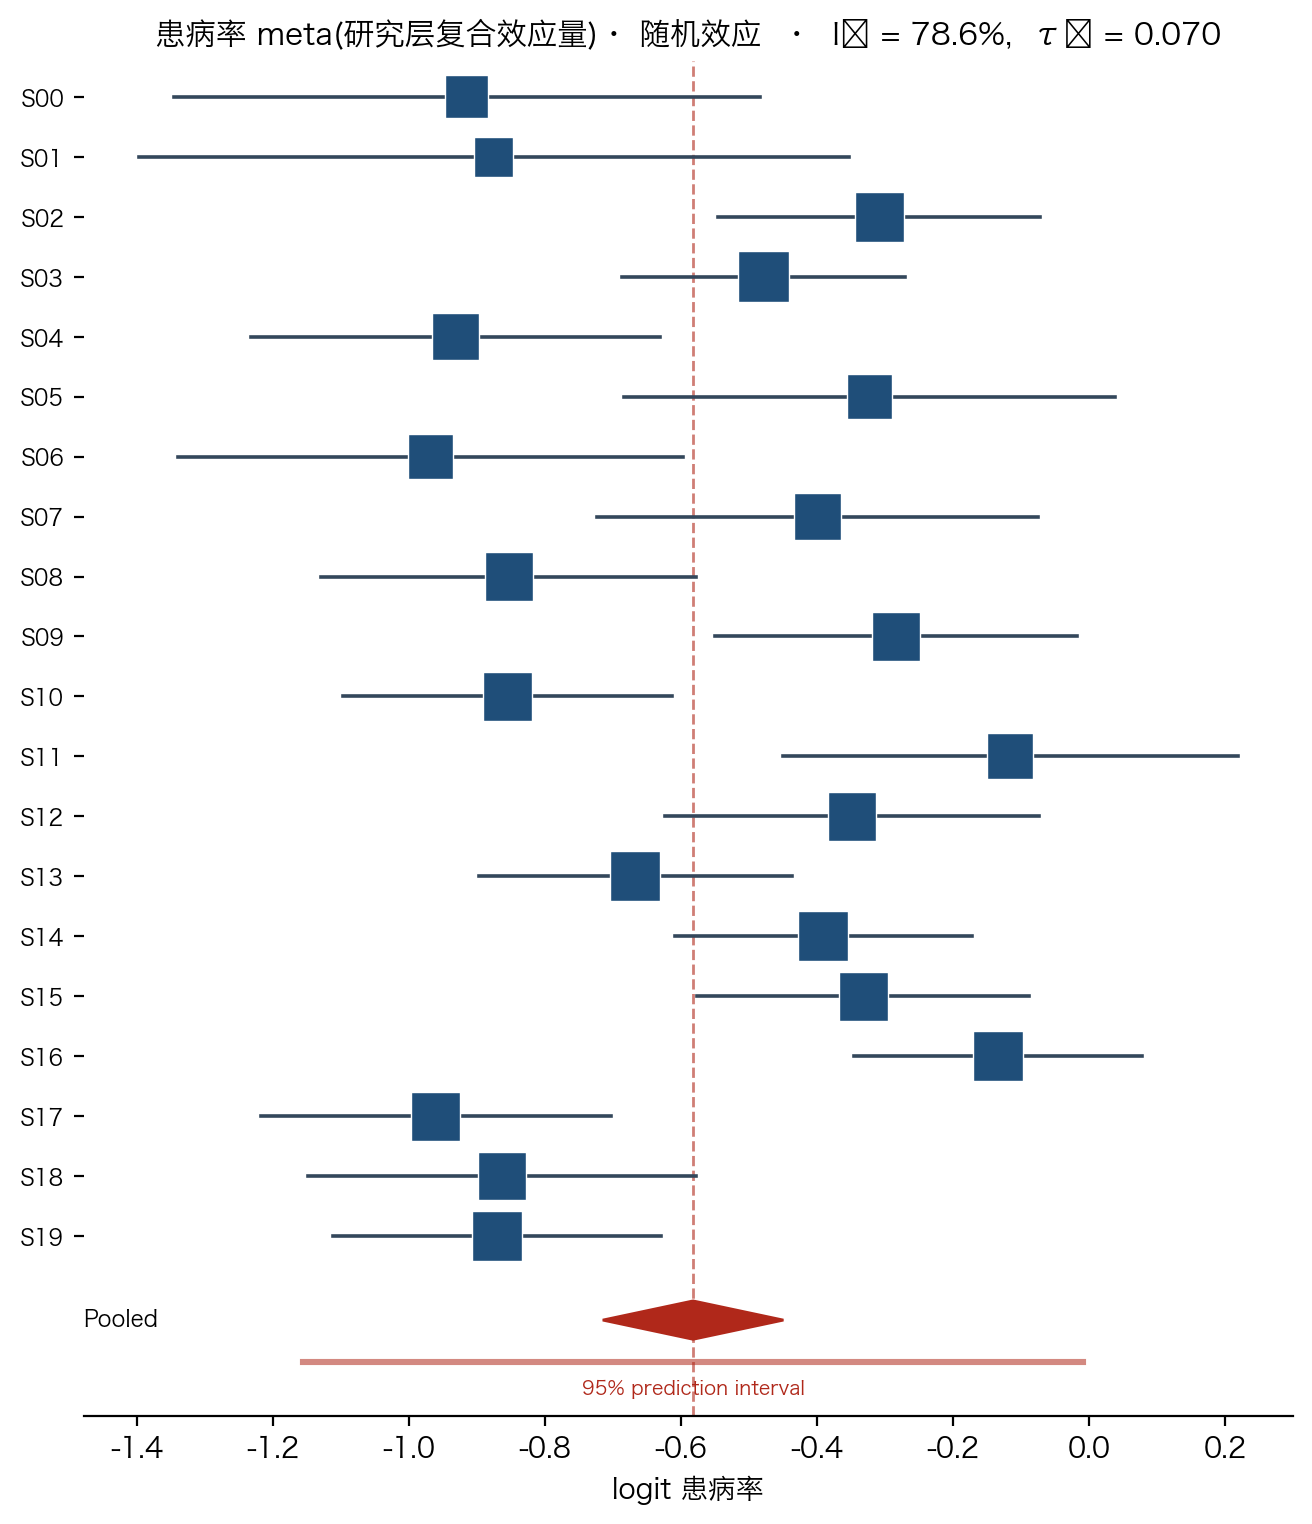

In [16]:
sv.tl.meta_heterogeneity(study_agg)
sv.tl.meta_prediction_interval(study_agg, level=0.95)
sv.pl.meta_forest(study_agg, out="fig23_forest.png",
                  title="患病率 meta(研究层复合效应量)· 随机效应",
                  xlab="logit 患病率")
Image("fig23_forest.png")

## 小结:相依效应量的两条稳健路线

同一批被试贡献的多个效应量**彼此相依**,把它们当独立会低估不确定性。我们用一份患病率 meta 走通了
两条互为印证的路线,每个数字都落在 `StudyState` 上、能追到是哪个 `sv.*` 函数算的:

```
比例(cases/n) ──sv.pp.es_proportion(PLO / PAS)──▶ 方差稳定的效应量(logit / arcsine)
  路线 A(建模协方差):
    ──sv.tl.vcalc(rho)──▶ 抽样协方差 V
    ──sv.tl.rma_mv──▶ 三层合并 + σ²₂(研究内)/ σ²₃(研究间)分解
    ──sv.tl.ma_i2_multilevel──▶ 分层 I²  ──sv.tl.tau2_ci / meta_prediction_interval──▶ 异质性区间
    ──sv.tl.ma_rho_sensitivity──▶ 结论对 ρ 稳健
  路线 B(稳健方差):
    ──sv.tl.ma_robust(CR2) / ma_che / robu(CORR)──▶ 簇稳健 SE,不依赖协方差假设
  简化替代:
    ──sv.pp.ma_aggregate──▶ 每研究一个复合效应量 ──sv.tl.meta_random──▶ 两层即可
  报告:
    ──sv.tl.backtransform_proportion──▶ 合并 logit/arcsine 回变换成患病率(≈ 35%,命中真值)
    ──sv.pl.meta_forest──▶ 一张图收束
```

**要点**:(1) 相依效应量**必先有簇列**;(2) 三层 `rma_mv` 告诉你异质性来自哪一层,CR2 稳健方差
给你不依赖假设的诚实 SE,两者结论应一致;(3) 任何 ρ 假设都要做敏感性;(4) 比例 meta 合并前变换、
报告前回变换。三层 σ²₂/σ²₃、CHE、CORR 与复合法都把患病率稳稳定在真值 35% 附近——证据链自洽。

下一本将进入**网络 meta 分析(netmeta)**:当研究比较的不是「干预 vs 对照」而是**多种干预两两之间**、
且没有一项研究同时比较所有干预时,如何借助**间接证据**把它们排到同一把尺子上。